In [1]:
import pandas as pd
import numpy as np
from scipy.linalg import sqrtm

def coral_align(Xs: pd.DataFrame, Xt: pd.DataFrame):
    """
    执行CORAL（Correlation Alignment）算法。
    将源域特征Xs变换，使其协方差矩阵与目标域特征Xt对齐。

    :param Xs: 源域特征 (Pandas DataFrame)
    :param Xt: 目标域特征 (Pandas DataFrame)
    :return: 变换后的源域特征 (Pandas DataFrame)
    """
    print("\n🔄 Starting CORAL alignment...")
    
    # 将DataFrame转换为Numpy数组以便进行数学运算
    Xs_np = Xs.values
    Xt_np = Xt.values
    
    # 1. 计算源域和目标域的协方差矩阵
    # rowvar=False 表示列是变量
    cov_s = np.cov(Xs_np, rowvar=False)
    cov_t = np.cov(Xt_np, rowvar=False)
    
    # 2. 为协方差矩阵添加一个微小的单位矩阵（正则化）
    # 这可以防止矩阵奇异（不可逆），提高数值稳定性
    cov_s = cov_s + np.eye(cov_s.shape[0]) * 1e-6
    cov_t = cov_t + np.eye(cov_t.shape[0]) * 1e-6

    # 3. 计算源域协方差矩阵的逆平方根
    # A_s = cov_s ^ (-1/2)
    A_s = sqrtm(np.linalg.inv(cov_s))
    
    # 4. 计算目标域协方差矩阵的平方根
    # B_t = cov_t ^ (1/2)
    B_t = sqrtm(cov_t)
    
    # 5. 计算变换矩阵
    transformation_matrix = np.dot(A_s, B_t)
    
    # 6. 对源域特征进行变换
    # Xs_aligned = Xs * transformation_matrix
    Xs_aligned_np = np.dot(Xs_np, transformation_matrix)
    
    # 由于数值计算的精度问题，结果可能包含微小的虚部，我们只取实部
    Xs_aligned_np = np.real(Xs_aligned_np)
    
    # 将变换后的Numpy数组转回保留列名的DataFrame
    Xs_aligned_df = pd.DataFrame(Xs_aligned_np, columns=Xs.columns)
    
    print("✅ CORAL alignment complete.")
    return Xs_aligned_df

# --- 主执行函数 ---
if __name__ == "__main__":
    
    # ========================= 用户配置区 =========================
    
    # 1. 指定源域和目标域的数据文件名
    SOURCE_DATA_FILE = '../data/features/dataset_complete.csv'
    TARGET_DATA_FILE = '../data/features/target/dataset_complete - 2.csv'
    
    # 2. **重要**: 在这里精确指定模型将要使用的【特征列】
    #    (根据您之前提供的列表)
    FEATURE_COLUMNS = [
        'rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 
        'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 
        'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE',
        'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE',
        'Env_Peak_BPFO_DE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE',
        'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE'
    ]

    # 3. 指定您的【标签列】
    LABEL_COLUMNS = ['PE', 'DeLoc', 'DeS']

    # ======================= 配置结束 ===========================

    # --- 步骤 1: 加载并准备数据 ---
    try:
        source_df = pd.read_csv(SOURCE_DATA_FILE)
        target_df = pd.read_csv(TARGET_DATA_FILE)
    except FileNotFoundError as e:
        print(f"❌ 错误：文件未找到。请检查文件名: {e}")
        exit()

    # --- 步骤 2: 精确筛选出用于对齐的特征和标签 ---
    # 确保所有指定的列都存在
    if not all(col in source_df.columns for col in FEATURE_COLUMNS + LABEL_COLUMNS):
        print("❌ 错误：源域数据中缺少部分指定的特征或标签列。")
        exit()
    if not all(col in target_df.columns for col in FEATURE_COLUMNS):
        print("❌ 错误：目标域数据中缺少部分指定的特征列。")
        exit()

    X_source = source_df[FEATURE_COLUMNS]
    y_source = source_df[LABEL_COLUMNS]
    X_target = target_df[FEATURE_COLUMNS]

    print(f"✅ 数据加载和筛选完成。")
    print(f"   - 源域特征维度: {X_source.shape}")
    print(f"   - 目标域特征维度: {X_target.shape}")

    # --- 步骤 3: 执行CORAL算法 ---
    X_source_aligned = coral_align(X_source, X_target)

    # --- 步骤 4: 合并变换后的源域特征与原始标签 ---
    aligned_source_dataset = pd.concat([y_source, X_source_aligned], axis=1)
    
    # --- 步骤 5: 保存结果 ---
    output_file = '../data/features/target/source_data_aligned.csv'
    aligned_source_dataset.to_csv(output_file, index=False)
    
    print(f"\n\n🎉 --- 迁移对齐完成 --- 🎉")
    print(f"✅ 经过CORAL变换后的源域数据集已保存到: '{output_file}'")
    print("   - 这个文件现在可以用于下一步的SMOTE数据增强和模型训练。")
    print("\n--- 对齐后源域数据预览 ---")
    print(aligned_source_dataset.head().to_string())

✅ 数据加载和筛选完成。
   - 源域特征维度: (411, 27)
   - 目标域特征维度: (16, 27)

🔄 Starting CORAL alignment...
✅ CORAL alignment complete.


🎉 --- 迁移对齐完成 --- 🎉
✅ 经过CORAL变换后的源域数据集已保存到: 'source_data_aligned.csv'
   - 这个文件现在可以用于下一步的SMOTE数据增强和模型训练。

--- 对齐后源域数据预览 ---
   PE DeLoc  DeS       rpm      Mean       RMS         Var      Skew      Kurt        CF        MF        P2P     FreqMean     FreqSTD  FreqSkew  FreqKurt  IR_Sideband_Energy_DE  IR_Sideband_Ratio_DE  B_Sideband_Energy_DE  B_Sideband_Ratio_DE  IR_Sideband_Energy_FE  IR_Sideband_Ratio_FE  B_Sideband_Energy_FE  B_Sideband_Ratio_FE  Env_Peak_BPFO_DE  Env_Peak_BPFI_DE  Env_Peak_BSF_DE  Env_Peak_BPFO_FE  Env_Peak_BPFI_FE  Env_Peak_BSF_FE
0  DE     B    7  0.073104  0.003637  0.068279  -39.482482 -0.289229 -2.581029 -3.817728 -4.069888 -53.943706  -117.399420  867.182945  0.393969 -0.834265           2.396682e+07             -3.978659          9.293954e+06          -384.333840           7.124609e+06             -5.765500          1.503705e+07           

✅ 数据加载和筛选完成。

🔄 Starting CORAL alignment...
✅ CORAL alignment complete.

🔄 Generating t-SNE distribution plots... (This may take a moment)
✅ t-SNE distribution comparison chart saved to 'coral_tsne_comparison.png'


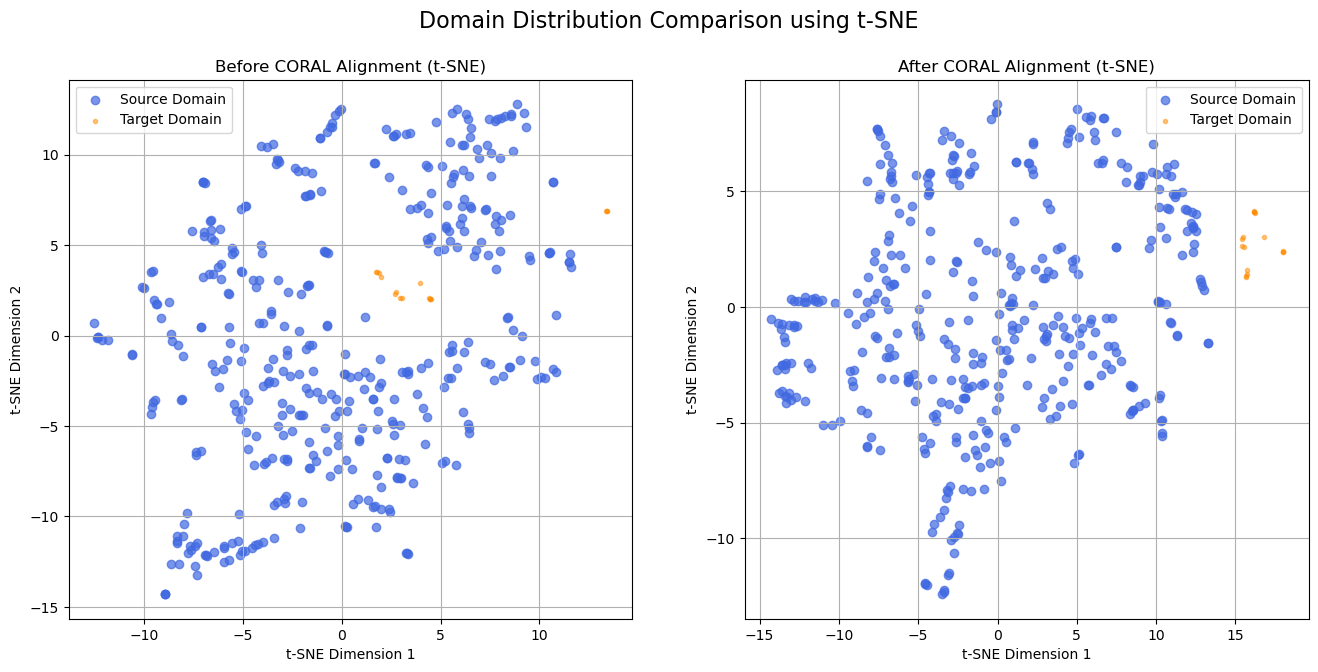

In [4]:
import pandas as pd
import numpy as np
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# 新增导入 TSNE
from sklearn.manifold import TSNE

def coral_align(Xs: pd.DataFrame, Xt: pd.DataFrame):
    """
    执行CORAL（Correlation Alignment）算法。
    """
    print("\n🔄 Starting CORAL alignment...")
    
    Xs_np = Xs.values
    Xt_np = Xt.values
    
    # 计算协方差矩阵并进行正则化
    cov_s = np.cov(Xs_np, rowvar=False) + np.eye(Xs_np.shape[1]) * 1e-6
    cov_t = np.cov(Xt_np, rowvar=False) + np.eye(Xt_np.shape[1]) * 1e-6

    # 计算变换矩阵
    A_s = sqrtm(np.linalg.inv(cov_s))
    B_t = sqrtm(cov_t)
    transformation_matrix = np.dot(A_s, B_t)
    
    # 对源域特征进行变换
    Xs_aligned_np = np.dot(Xs_np, transformation_matrix)
    Xs_aligned_np = np.real(Xs_aligned_np)
    
    Xs_aligned_df = pd.DataFrame(Xs_aligned_np, columns=Xs.columns)
    
    print("✅ CORAL alignment complete.")
    return Xs_aligned_df

# --- 【新增】使用t-SNE的降维与绘图函数 ---
def plot_domain_distribution_tsne(Xs, Xt, Xs_aligned):
    """
    使用t-SNE降维，对比展示CORAL变换前后的数据分布。
    """
    print("\n🔄 Generating t-SNE distribution plots... (This may take a moment)")
    
    # --- 步骤 1: 准备数据 ---
    # t-SNE对数据尺度敏感，我们先对所有数据进行标准化
    scaler = StandardScaler()
    Xs_scaled = scaler.fit_transform(Xs)
    Xt_scaled = scaler.transform(Xt)
    # 对齐后的数据也需要基于其自身分布进行标准化，以获得最佳可视化效果
    Xs_aligned_scaled = StandardScaler().fit_transform(Xs_aligned)

    # 创建t-SNE对象
    # perplexity 通常设置为 5-50，数据点越多值可以越大
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=300)
    
    # --- 步骤 2: 变换前 ---
    # 将变换前的源域和目标域数据合并，一同进行t-SNE降维
    combined_before = np.vstack((Xs_scaled, Xt_scaled))
    tsne_results_before = tsne.fit_transform(combined_before)
    
    Xs_tsne_before = tsne_results_before[:len(Xs_scaled)]
    Xt_tsne_before = tsne_results_before[len(Xs_scaled):]

    # --- 步骤 3: 变换后 ---
    # 将变换后的源域和目标域数据合并，一同进行t-SNE降维
    combined_after = np.vstack((Xs_aligned_scaled, Xt_scaled))
    tsne_results_after = tsne.fit_transform(combined_after)

    Xs_tsne_after = tsne_results_after[:len(Xs_aligned_scaled)]
    Xt_tsne_after = tsne_results_after[len(Xs_aligned_scaled):]

    # --- 步骤 4: 创建画布并绘图 ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # 绘制左图：变换前
    ax1.scatter(Xs_tsne_before[:, 0], Xs_tsne_before[:, 1], c='royalblue', marker='o', label='Source Domain', alpha=0.7)
    ax1.scatter(Xt_tsne_before[:, 0], Xt_tsne_before[:, 1], c='darkorange', marker='.', label='Target Domain', alpha=0.5)
    ax1.set_title('Before CORAL Alignment (t-SNE)')
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.legend()
    ax1.grid(True)

    # 绘制右图：变换后
    ax2.scatter(Xs_tsne_after[:, 0], Xs_tsne_after[:, 1], c='royalblue', marker='o', label='Source Domain', alpha=0.7)
    ax2.scatter(Xt_tsne_after[:, 0], Xt_tsne_after[:, 1], c='darkorange', marker='.', label='Target Domain', alpha=0.5)
    ax2.set_title('After CORAL Alignment (t-SNE)')
    ax2.set_xlabel('t-SNE Dimension 1')
    ax2.set_ylabel('t-SNE Dimension 2')
    ax2.legend()
    ax2.grid(True)

    fig.suptitle('Domain Distribution Comparison using t-SNE', fontsize=16)
    plt.savefig('../results/02_迁移诊断/coral_tsne_comparison.png')
    print("✅ t-SNE distribution comparison chart saved to '../results/02_迁移诊断/coral_tsne_comparison.png'")
    plt.show()


# --- 主执行函数 ---
if __name__ == "__main__":
    
    # ========================= 用户配置区 =========================
    SOURCE_DATA_FILE = '../data/features/dataset_complete.csv'
    TARGET_DATA_FILE = '../data/features/target/dataset_complete - 2.csv'
    
    FEATURE_COLUMNS = [
        'rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 
        'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 
        'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE',
        'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE',
        'Env_Peak_BPFO_DE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE',
        'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE'
    ]
    LABEL_COLUMNS = ['PE', 'DeLoc', 'DeS']
    # ======================= 配置结束 ===========================

    try:
        source_df = pd.read_csv(SOURCE_DATA_FILE)
        target_df = pd.read_csv(TARGET_DATA_FILE)
    except FileNotFoundError as e:
        print(f"❌ 错误：文件未找到。请检查文件名: {e}")
        exit()

    X_source = source_df[FEATURE_COLUMNS]
    y_source = source_df[LABEL_COLUMNS] # y_source在这里暂时不用，但保留以备后用
    X_target = target_df[FEATURE_COLUMNS]
    print(f"✅ 数据加载和筛选完成。")

    # 执行CORAL算法
    X_source_aligned = coral_align(X_source, X_target)

    # 调用t-SNE绘图函数进行可视化
    plot_domain_distribution_tsne(
        Xs=X_source, 
        Xt=X_target, 
        Xs_aligned=X_source_aligned
    )

✅ 数据加载和筛选完成。

🔄 Applying consistent standardization...

🔄 Starting CORAL alignment on scaled data...
✅ CORAL alignment complete.

🔄 Generating t-SNE distribution plots...
✅ Corrected t-SNE chart saved to 'coral_tsne_comparison_corrected.png'


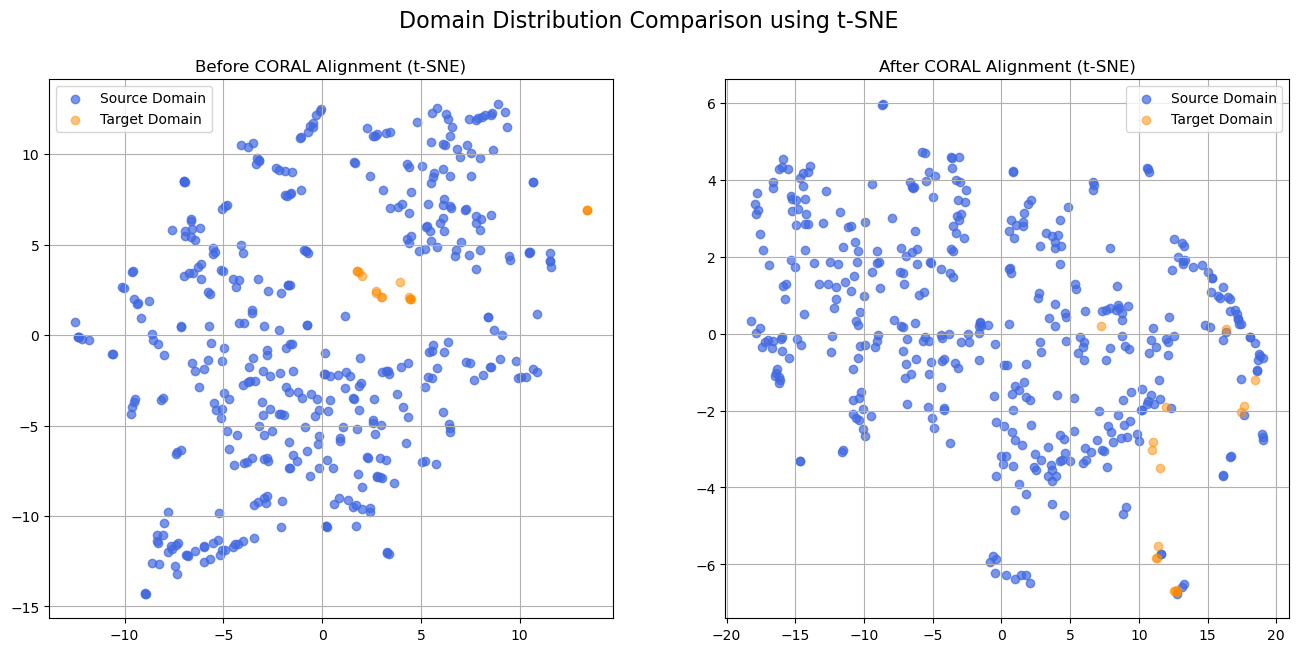

In [5]:
import pandas as pd
import numpy as np
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

def coral_align(Xs: np.ndarray, Xt: np.ndarray) -> np.ndarray:
    """
    对【已经标准化过】的Numpy数组执行CORAL算法。
    """
    print("\n🔄 Starting CORAL alignment on scaled data...")
    
    # 输入已经是Numpy数组，无需转换
    cov_s = np.cov(Xs, rowvar=False) + np.eye(Xs.shape[1]) * 1e-6
    cov_t = np.cov(Xt, rowvar=False) + np.eye(Xt.shape[1]) * 1e-6

    A_s = sqrtm(np.linalg.inv(cov_s))
    B_t = sqrtm(cov_t)
    
    transformation_matrix = np.dot(A_s, B_t)
    
    Xs_aligned_np = np.dot(Xs, transformation_matrix)
    Xs_aligned_np = np.real(Xs_aligned_np)
    
    print("✅ CORAL alignment complete.")
    return Xs_aligned_np

def plot_domain_distribution_tsne(Xs_scaled, Xt_scaled, Xs_aligned_scaled):
    """
    使用t-SNE降维，对比展示CORAL变换前后的数据分布。
    """
    print("\n🔄 Generating t-SNE distribution plots...")
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=300)
    
    # --- 变换前 ---
    combined_before = np.vstack((Xs_scaled, Xt_scaled))
    tsne_results_before = tsne.fit_transform(combined_before)
    Xs_tsne_before = tsne_results_before[:len(Xs_scaled)]
    Xt_tsne_before = tsne_results_before[len(Xs_scaled):]

    # --- 变换后 ---
    # **核心修正**: 这里的Xs_aligned_scaled是直接从外部传入的，保证了尺度一致
    combined_after = np.vstack((Xs_aligned_scaled, Xt_scaled))
    tsne_results_after = tsne.fit_transform(combined_after)
    Xs_tsne_after = tsne_results_after[:len(Xs_aligned_scaled)]
    Xt_tsne_after = tsne_results_after[len(Xs_aligned_scaled):]

    # --- 绘图 ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    ax1.scatter(Xs_tsne_before[:, 0], Xs_tsne_before[:, 1], c='royalblue', label='Source Domain', alpha=0.7)
    ax1.scatter(Xt_tsne_before[:, 0], Xt_tsne_before[:, 1], c='darkorange', label='Target Domain', alpha=0.5)
    ax1.set_title('Before CORAL Alignment (t-SNE)')
    ax1.legend(); ax1.grid(True)

    ax2.scatter(Xs_tsne_after[:, 0], Xs_tsne_after[:, 1], c='royalblue', label='Source Domain', alpha=0.7)
    ax2.scatter(Xt_tsne_after[:, 0], Xt_tsne_after[:, 1], c='darkorange', label='Target Domain', alpha=0.5)
    ax2.set_title('After CORAL Alignment (t-SNE)')
    ax2.legend(); ax2.grid(True)

    fig.suptitle('Domain Distribution Comparison using t-SNE', fontsize=16)
    plt.savefig('../results/02_迁移诊断/coral_tsne_comparison_corrected.png')
    print("✅ Corrected t-SNE chart saved to '../results/02_迁移诊断/coral_tsne_comparison_corrected.png'")
    plt.show()

if __name__ == "__main__":
    SOURCE_DATA_FILE = '../data/features/dataset_complete.csv'
    TARGET_DATA_FILE = '../data/features/target/dataset_complete - 2.csv'
    FEATURE_COLUMNS = [
        'rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 
        'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 
        'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE',
        'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE',
        'Env_Peak_BPFO_DE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE',
        'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE'
    ]
    LABEL_COLUMNS = ['PE', 'DeLoc', 'DeS']

    try:
        source_df = pd.read_csv(SOURCE_DATA_FILE)
        target_df = pd.read_csv(TARGET_DATA_FILE)
    except FileNotFoundError as e:
        print(f"❌ 错误：文件未找到。请检查文件名: {e}"); exit()

    X_source = source_df[FEATURE_COLUMNS]
    y_source = source_df[LABEL_COLUMNS]
    X_target = target_df[FEATURE_COLUMNS]
    print(f"✅ 数据加载和筛选完成。")

    # --- **核心修正**: 统一的、前置的标准化流程 ---
    print("\n🔄 Applying consistent standardization...")
    scaler = StandardScaler()
    # 在源域上fit，然后transform源域和目标域
    X_source_scaled = scaler.fit_transform(X_source)
    X_target_scaled = scaler.transform(X_target)
    
    # --- 在【标准化之后】的数据上执行CORAL ---
    X_source_aligned_scaled = coral_align(X_source_scaled, X_target_scaled)

    # --- 调用绘图函数 ---
    plot_domain_distribution_tsne(
        Xs_scaled=X_source_scaled, 
        Xt_scaled=X_target_scaled, 
        Xs_aligned_scaled=X_source_aligned_scaled
    )

    # --- 最后，您可以选择性地保存对齐后的数据 ---
    # 注意：此时保存的数据是已经标准化过的
    # aligned_source_dataset = pd.concat([y_source, pd.DataFrame(X_source_aligned_scaled, columns=FEATURE_COLUMNS)], axis=1)
    # aligned_source_dataset.to_csv('../data/features/target/source_data_aligned_scaled.csv', index=False)

✅ 数据加载和筛选完成。

🔄 Applying consistent standardization...

🔄 Starting CORAL alignment on scaled data...
✅ CORAL alignment complete.

🔄 Generating t-SNE distribution plots... (This may take a moment)
✅ t-SNE chart with unified axes saved to 'coral_tsne_comparison_unified_axes.png'


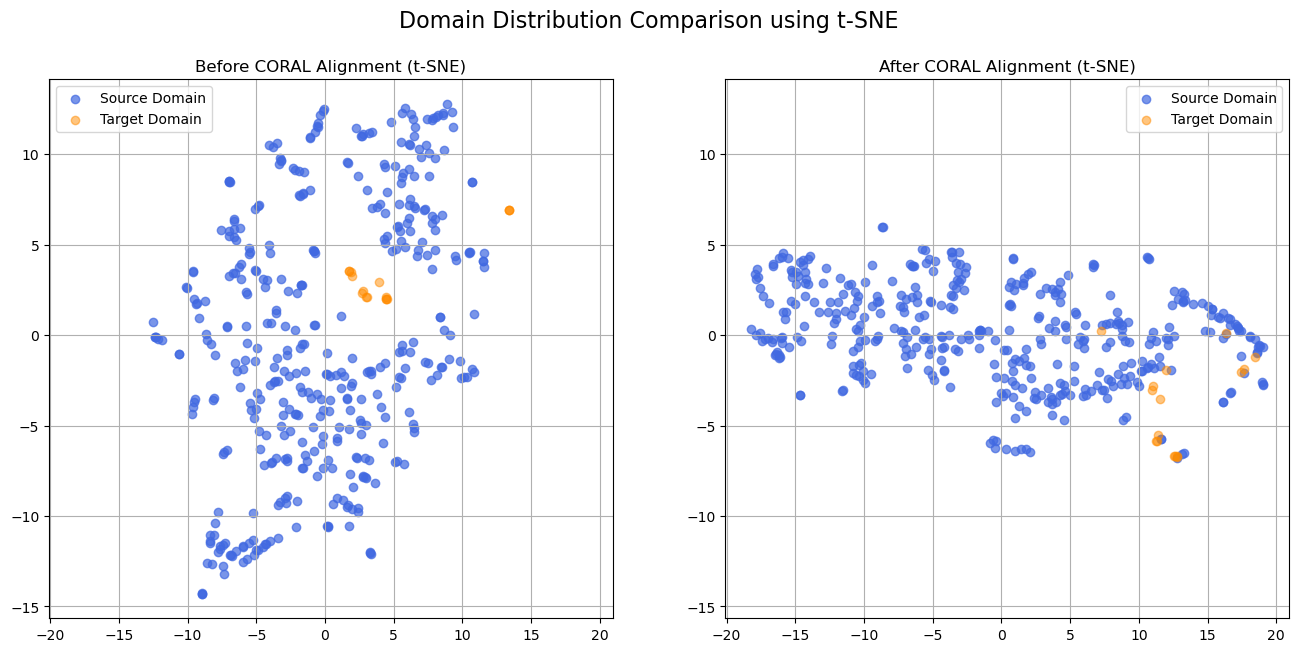

In [6]:
import pandas as pd
import numpy as np
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

def coral_align(Xs: np.ndarray, Xt: np.ndarray) -> np.ndarray:
    """
    对【已经标准化过】的Numpy数组执行CORAL算法。
    """
    print("\n🔄 Starting CORAL alignment on scaled data...")
    
    cov_s = np.cov(Xs, rowvar=False) + np.eye(Xs.shape[1]) * 1e-6
    cov_t = np.cov(Xt, rowvar=False) + np.eye(Xt.shape[1]) * 1e-6

    A_s = sqrtm(np.linalg.inv(cov_s))
    B_t = sqrtm(cov_t)
    
    transformation_matrix = np.dot(A_s, B_t)
    
    Xs_aligned_np = np.dot(Xs, transformation_matrix)
    Xs_aligned_np = np.real(Xs_aligned_np)
    
    print("✅ CORAL alignment complete.")
    return Xs_aligned_np

def plot_domain_distribution_tsne(Xs_scaled, Xt_scaled, Xs_aligned_scaled):
    """
    使用t-SNE降维，对比展示CORAL变换前后的数据分布。
    此版本会统一坐标轴范围。
    """
    print("\n🔄 Generating t-SNE distribution plots... (This may take a moment)")
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=300)
    
    # --- 变换前 ---
    combined_before = np.vstack((Xs_scaled, Xt_scaled))
    tsne_results_before = tsne.fit_transform(combined_before)
    Xs_tsne_before = tsne_results_before[:len(Xs_scaled)]
    Xt_tsne_before = tsne_results_before[len(Xs_scaled):]

    # --- 变换后 ---
    combined_after = np.vstack((Xs_aligned_scaled, Xt_scaled))
    tsne_results_after = tsne.fit_transform(combined_after)
    Xs_tsne_after = tsne_results_after[:len(Xs_aligned_scaled)]
    Xt_tsne_after = tsne_results_after[len(Xs_aligned_scaled):]

    # --- 绘图 ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # 左图：变换前
    ax1.scatter(Xs_tsne_before[:, 0], Xs_tsne_before[:, 1], c='royalblue', label='Source Domain', alpha=0.7)
    ax1.scatter(Xt_tsne_before[:, 0], Xt_tsne_before[:, 1], c='darkorange', label='Target Domain', alpha=0.5)
    ax1.set_title('Before CORAL Alignment (t-SNE)')
    ax1.legend(); ax1.grid(True)

    # 右图：变换后
    ax2.scatter(Xs_tsne_after[:, 0], Xs_tsne_after[:, 1], c='royalblue', label='Source Domain', alpha=0.7)
    ax2.scatter(Xt_tsne_after[:, 0], Xt_tsne_after[:, 1], c='darkorange', label='Target Domain', alpha=0.5)
    ax2.set_title('After CORAL Alignment (t-SNE)')
    ax2.legend(); ax2.grid(True)

    # --- 【新增】统一坐标轴范围 ---
    # 1. 找到所有数据点x和y坐标的全局最小值和最大值
    all_x_coords = np.concatenate([tsne_results_before[:, 0], tsne_results_after[:, 0]])
    all_y_coords = np.concatenate([tsne_results_before[:, 1], tsne_results_after[:, 1]])
    
    x_min, x_max = all_x_coords.min(), all_x_coords.max()
    y_min, y_max = all_y_coords.min(), all_y_coords.max()
    
    # 2. 增加一点边距(padding)，让图像更好看
    x_padding = (x_max - x_min) * 0.05
    y_padding = (y_max - y_min) * 0.05
    
    # 3. 将统一的范围应用到两个子图上
    ax1.set_xlim(x_min - x_padding, x_max + x_padding)
    ax1.set_ylim(y_min - y_padding, y_max + y_padding)
    ax2.set_xlim(x_min - x_padding, x_max + x_padding)
    ax2.set_ylim(y_min - y_padding, y_max + y_padding)
    # --- 新增结束 ---

    fig.suptitle('Domain Distribution Comparison using t-SNE', fontsize=16)
    plt.savefig('../results/02_迁移诊断/coral_tsne_comparison_unified_axes.png')
    print("✅ t-SNE chart with unified axes saved to '../results/02_迁移诊断/coral_tsne_comparison_unified_axes.png'")
    plt.show()

# --- 主执行函数 ---
if __name__ == "__main__":
    
    SOURCE_DATA_FILE = '../data/features/dataset_complete.csv'
    TARGET_DATA_FILE = '../data/features/target/dataset_complete - 2.csv'
    FEATURE_COLUMNS = [
        'rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 
        'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 
        'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE',
        'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE',
        'Env_Peak_BPFO_DE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE',
        'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE'
    ]
    LABEL_COLUMNS = ['PE', 'DeLoc', 'DeS']

    try:
        source_df = pd.read_csv(SOURCE_DATA_FILE)
        target_df = pd.read_csv(TARGET_DATA_FILE)
    except FileNotFoundError as e:
        print(f"❌ 错误：文件未找到。请检查文件名: {e}"); exit()

    X_source = source_df[FEATURE_COLUMNS]
    y_source = source_df[LABEL_COLUMNS]
    X_target = target_df[FEATURE_COLUMNS]
    print(f"✅ 数据加载和筛选完成。")

    print("\n🔄 Applying consistent standardization...")
    scaler = StandardScaler()
    X_source_scaled = scaler.fit_transform(X_source)
    X_target_scaled = scaler.transform(X_target)
    
    X_source_aligned_scaled = coral_align(X_source_scaled, X_target_scaled)

    plot_domain_distribution_tsne(
        Xs_scaled=X_source_scaled, 
        Xt_scaled=X_target_scaled, 
        Xs_aligned_scaled=X_source_aligned_scaled
    )

    # aligned_source_dataset = pd.concat([y_source, pd.DataFrame(X_source_aligned_scaled, columns=FEATURE_COLUMNS)], axis=1)
    # aligned_source_dataset.to_csv('../data/features/target/source_data_aligned_scaled.csv', index=False)